#Entrenamiento

Se utiliza una extracción de caracteristicas generales y otro caso con caracteristicas como las carcteristicas espectrales en ventanas temporales. Además se hace uso de la medida **LF** y **HF** en relacion a la regulación simpática y parasimática.
Esto para intentar tomar encuenta **relajación** y **estrés/esfuerzo**.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/pract5CDSIsensadoFisio/dataset_final10.csv")

In [ ]:
features = ['hrv_mean', 'hrv_std', 'hrv_rmssd', 'hrv_change', 'LF', 'HF', 'LF_HF_ratio']
X = df[features]
y = df['fear level']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



## Comparación de Modelos de Clasificación

En esta sección, entrenamos y evaluamos **5 modelos de clasificación**:
1. **Regresión Logística**
2. **K-Nearest Neighbors  con 5 vecinos
3. **Random Forest**
4. **SVM** con kernel radial (RBF)
5. **XGBoost** (configuración estándar)

**Métricas utilizadas**:
- **Exactitud (Accuracy)**: Porcentaje de predicciones correctas.
- **F1-Score (promedio ponderado)**: Balance entre precisión y recall, útil para clases desbalanceadas.

**Visualización**:
- Se generan matrices de confusión para cada modelo en una cuadrícula de 2x3.
- Cada gráfico incluye las métricas en el título.

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:45:56] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


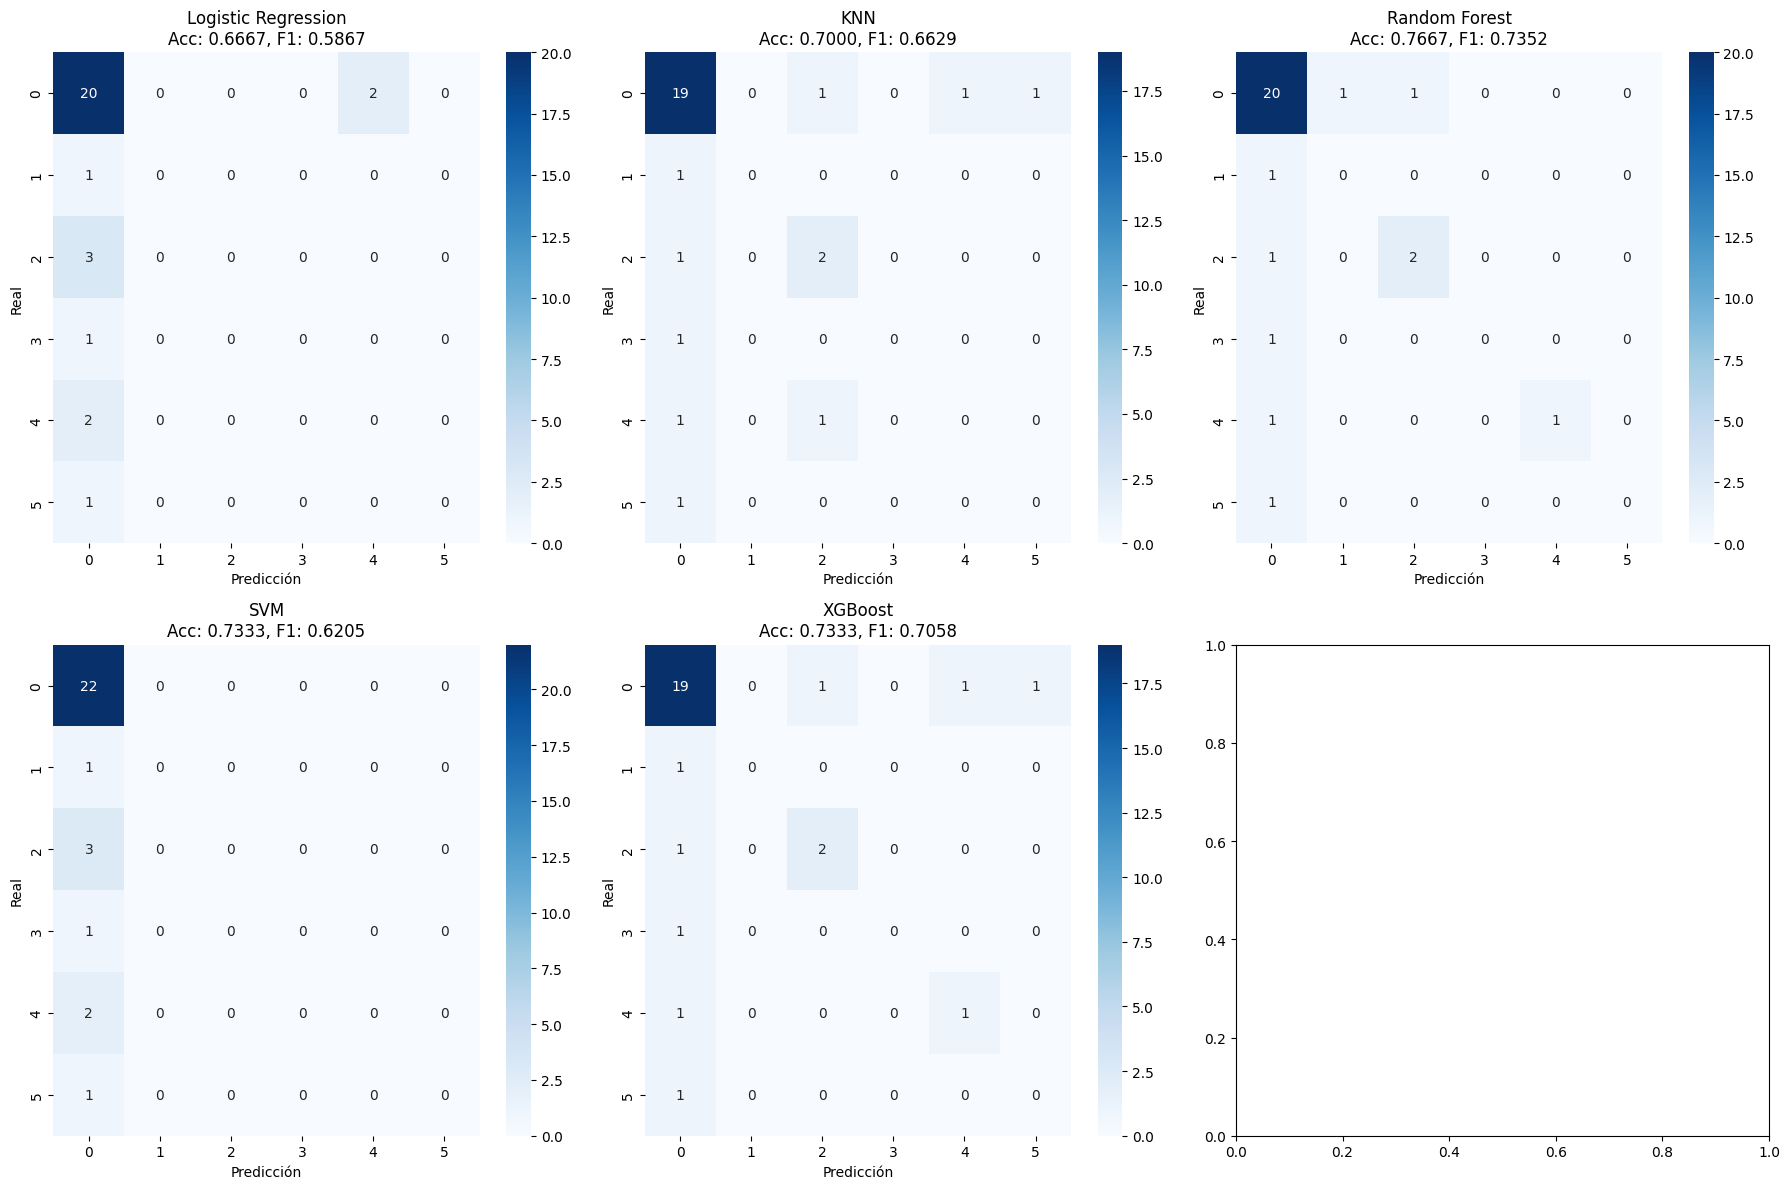

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')


    cm = confusion_matrix(y_test, y_pred)


    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y), ax=axes[i])
    axes[i].set_title(f"{name}\nAcc: {acc:.4f}, F1: {f1:.4f}")
    axes[i].set_xlabel("Predicción")
    axes[i].set_ylabel("Real")


plt.tight_layout()
plt.show()

##**Análisis de Resultados**:
### - Los resultados fueron muy similares en cada caso, ya que teniamos pocas instancias que si bien eran significativas en conjunto la mayoria de casos de nivel miedo 0 sobrepasaba los otros niveles de miedo, dandonos una pobre clasificación de los niveles de miedo




---



# Modelo LSTM para Predicción de Niveles de Miedo basado en HRV

## Predecir el nivel de miedo `fear level` en tiempo real usando series temporales de HRV.



**Preparación de Datos**:
   - Segmentación por usuario.
   - Creación de secuencias temporales de 10.




/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.6133 - loss: 1.2613 - val_accuracy: 0.6505 - val_loss: 1.0119
Epoch 2/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6635 - loss: 0.9867 - val_accuracy: 0.6390 - val_loss: 0.9915
Epoch 3/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6774 - loss: 0.9492 - val_accuracy: 0.6667 - val_loss: 0.9364
Epoch 4/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6827 - loss: 0.9206 - val_accuracy: 0.7005 - val_loss: 0.9006
Epoch 5/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6905 - loss: 0.9106 - val_accuracy: 0.6967 - val_loss: 0.8899
Epoch 6/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7003 - loss: 0.8870 - val_accuracy: 0.6867 - val_loss: 0.8998
Epoch 7/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7190 - loss: 0.8601 - val_accuracy: 0.7021 - val_loss: 0.8860
Epoch 8/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7007 - loss: 0.8655 - val_acc

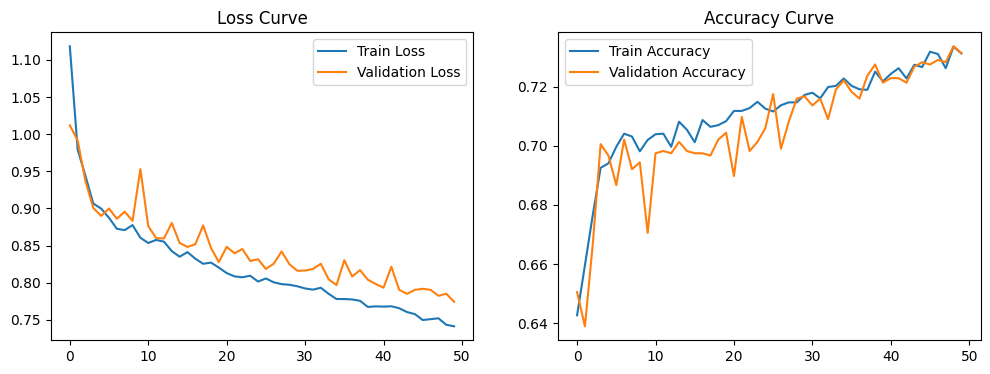

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder


df = pd.read_csv("/content/drive/MyDrive/pract5CDSIsensadoFisio/hrv_datos_limpios.csv")
scaler = StandardScaler()
df['hrv'] = scaler.fit_transform(df[['hrv']])


label_encoder = LabelEncoder()
df['fear level'] = label_encoder.fit_transform(df['fear level'])


user_groups = df.groupby("user")


sequence_length = 10
X, y = [], []

for _, group in user_groups:
    values = group[['hrv']].values
    labels = group['fear level'].values


    for i in range(len(values) - sequence_length):
        X.append(values[i:i+sequence_length])
        y.append(labels[i+sequence_length])


X = np.array(X)
y = np.array(y)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(sequence_length, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(len(np.unique(y)), activation='softmax')
])


model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")

plt.show()


# Resultados

### Para este caso hubo un mejor aprendizaje de los distintos niveles de miedo y sus diferencias. Aunque bastantes error para el nivel 1 y 2, si vemos las graficas de los participantes los picos para estos niveles eran bastantes similares en valor de la toma HRV

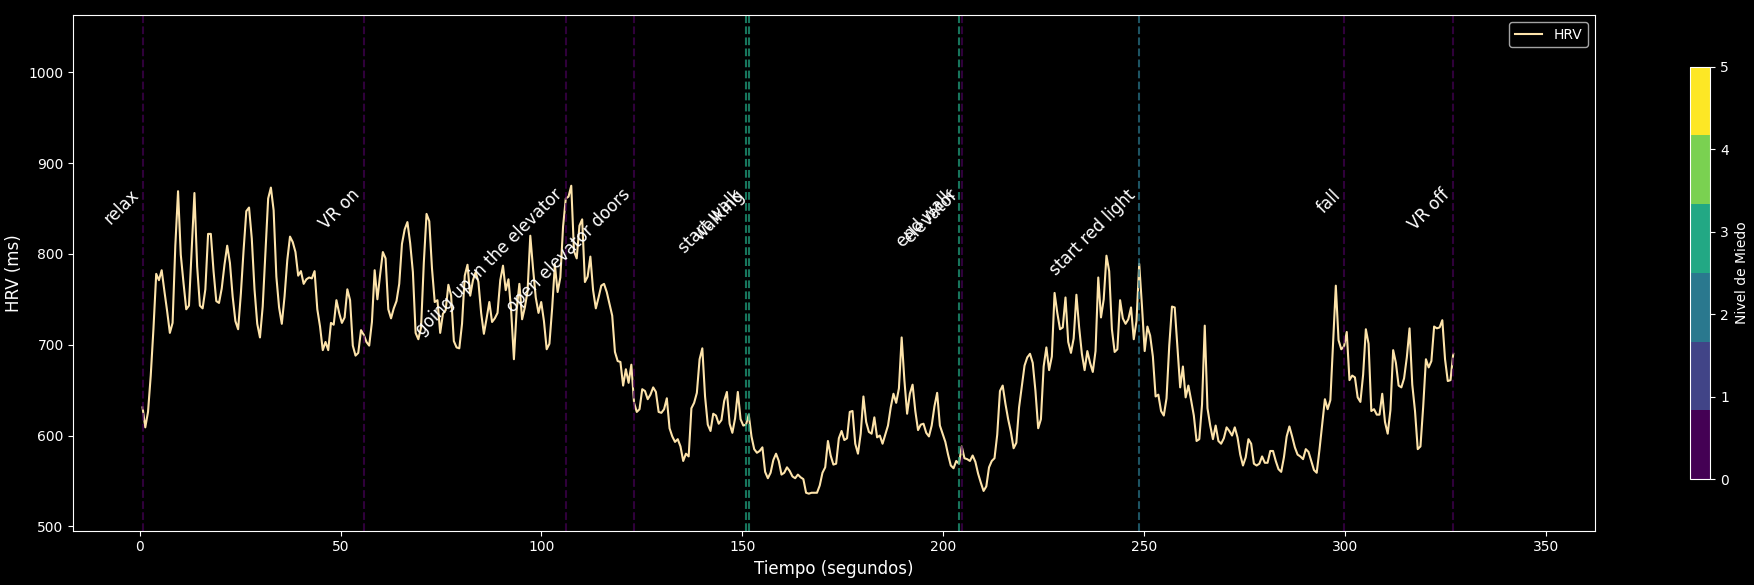

### De igual forma el miedo al ser anotado por un observador resulta subjetivo, además algunas de las anotaciones parecen no cuadrar con las lecturas en casos particulares, esto puede ser también por que en realidad la "expresión del miedo" era mayor a lo que sentia realmente.

### Sin embargo podríamos decir que detectar un estado de relajacióon o neutral resulta bastante sencillo, gracias a la cantidad de estos estados. Así como los niveles de mayor miedo en el caso de los participantes que reaccionaban más ante estos efectos.

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


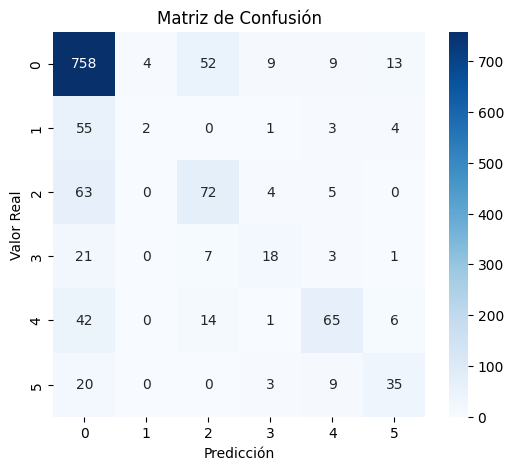

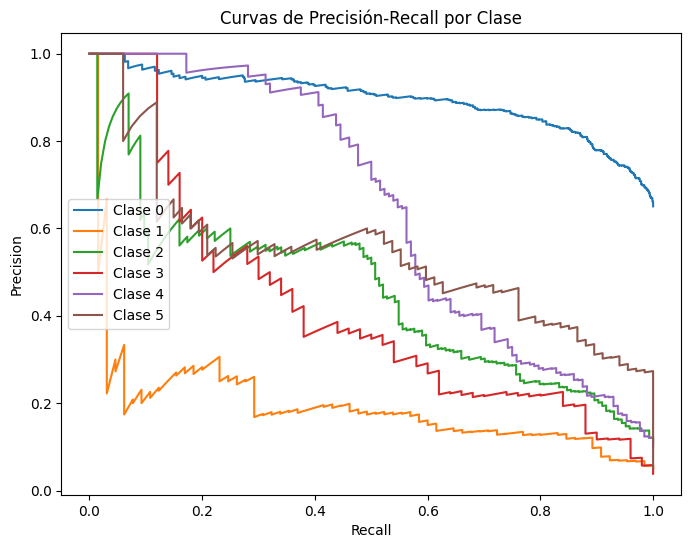

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve


y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión")
plt.show()

plt.figure(figsize=(8, 6))
for i in range(y_pred_probs.shape[1]):
    precision, recall, _ = precision_recall_curve(y_test == i, y_pred_probs[:, i])
    plt.plot(recall, precision, label=f'Clase {i}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curvas de Precisión-Recall por Clase')
plt.legend()
plt.show()



